<a href="https://colab.research.google.com/github/Manar-00/ML-projects/blob/main/breast_cancer2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mini machine learning project for breast cancer classification. The project aims to predict whether a tumor is benign or malignant using a breast cancer dataset. Supervised learning techniques were applied, including linear and non-linear SVM models, as well as unsupervised learning methods such as K-Means and Hierarchical Clustering. The results were analyzed and compared to evaluate the performance of the different models.

In [ ]:
# منار تركي أحمد -شعبة 2

In [ ]:
# import the important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings("ignore")
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

In [ ]:
# I import the data using this code
# I want to drop the ID coulm (it maybe overfit the model) and encooding the target but this steps well done befor in the data, so no need
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
# df["target"] = data.target # This line is redundant as data.frame already includes 'target'

X_bc = df.drop(columns=['target']) # Define X_bc as features
y_bc = df['target'] # Define y_bc as target

print(X_bc.head())
print(X_bc.info())
print(X_bc.describe())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [ ]:
# Features (X) and target (y)
X = df.drop(columns=["target"])
y = df["target"]

# Train/test split (just for SVM)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
# The values in the cancer data have different ranges, and the SVM model uses distance measurement for classification,
# so they must be standardized and adjusted to a specific range to avoid bias or incorrect classification.
# I fit only for the training data so that the test data is not leaked to the model.
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

model 1: 
Predicted labels: [0 1 1 0 0 0 1 0 1 0 1 1 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 0 0 1 0 1 1 0 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 0 0 1 1 0 1 1 1 0 0 0 1 1 1 1 0 1 1 0 0 0 0
 1 1 1 1 0 1 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 0
 1 0 1 1 0 0 1 1 0 1 1 0 1 0 1 1 0 1 1 1 1 0 1 0 1 0 1 0 1 1 1 0 0 0 0 0 1
 0 1 1 1 0 1 0 1 1 0 1 1 0 0 1 1 0 1 1 1 1 0 1]
Accuracy: 0.9824561403508771

Classification Report:
               precision    recall  f1-score   support

   malignant       0.98      0.97      0.98        64
      benign       0.98      0.99      0.99       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



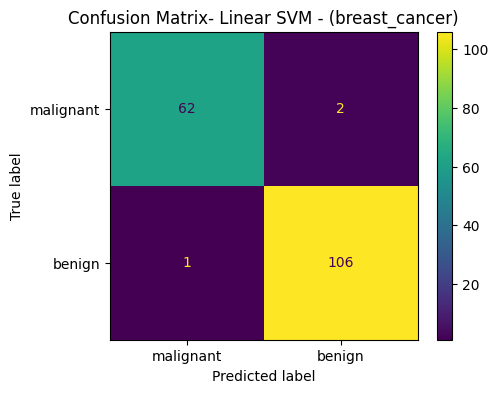

In [ ]:
# Linear SVM model (model 1)
# Model building and training
svm_linear = SVC(kernel='linear', C=1.0, probability=True)
svm_linear.fit(X_train_scaled, y_train)

# using this cood i tried many value for c by grid search but the value c=1.0 give me the best result
#param_grid_linear = {
#  "C": [0.01, 0.1, 1, 10, 100]}
#   gs_linear = GridSearchCV(
#   estimator=SVC(kernel="linear", probability=True),
#    param_grid=param_grid_linear,
#   scoring="f1",
#    cv=5,
#   n_jobs=-1,
#   verbose=1
# )
# gs_linear.fit(X_train_scaled, y_train)

print("model 1: ")
# Make Predictions for model 1
y_pred1 = svm_linear.predict(X_test_scaled)
print("Predicted labels:", y_pred1)

# Evaluate the Model 1
accuracy = accuracy_score(y_test, y_pred1)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred1, target_names=['malignant', 'benign']))

# Confusion Matrix for model 1
labels = list(data.target_names) # ['malignant', 'benign']
cm = confusion_matrix(y_test, y_pred1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax)
plt.title("Confusion Matrix- Linear SVM - (breast_cancer)")
plt.show()

Fitting 5 folds for each of 16 candidates, totalling 80 fits
model 2: 
Predicted labels: [0 1 1 0 1 0 1 0 1 0 1 1 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 0 0 1 0 1 1 0 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 0 0 1 1 0 1 1 1 0 0 0 1 1 1 1 0 1 1 0 0 0 0
 1 1 1 1 0 1 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 0
 1 0 1 1 0 1 1 1 0 1 1 0 1 0 1 1 0 1 1 1 1 0 1 0 1 0 1 0 1 1 1 0 0 0 0 0 1
 0 1 1 1 0 1 0 1 1 0 1 1 0 0 1 1 0 1 1 1 1 0 1]
Accuracy: 0.9707602339181286

Classification Report:
               precision    recall  f1-score   support

   malignant       0.98      0.94      0.96        64
      benign       0.96      0.99      0.98       107

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



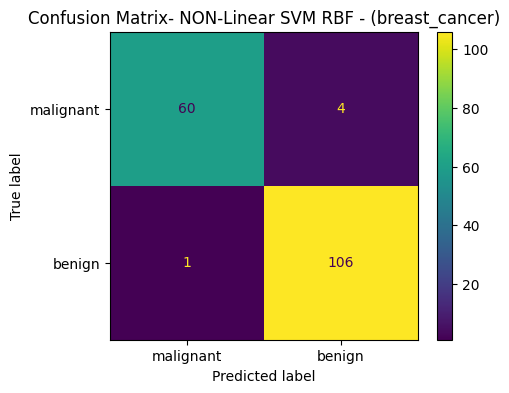

In [ ]:
# NON-Linear SVM (RBF)(model 2)
# Model building and training
param_grid_rbf = {
    "C": [0.1, 1, 10, 100],
    "gamma": ['scale', 'auto', 0.01, 0.001]
}
gs_rbf = GridSearchCV(
    estimator=SVC(kernel="rbf", probability=True),
    param_grid=param_grid_rbf,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)
gs_rbf.fit(X_train_scaled, y_train)

print("model 2: ")
# Make Predictions for model 2
y_pred2 = gs_rbf.predict(X_test_scaled)
print("Predicted labels:", y_pred2)

# Evaluate the Model2
accuracy = accuracy_score(y_test, y_pred2)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred2, target_names=['malignant', 'benign']))


# Confusion Matrix for model 2
labels = list(data.target_names) # ['malignant', 'benign']
cm = confusion_matrix(y_test, y_pred2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax)
plt.title("Confusion Matrix- NON-Linear SVM RBF - (breast_cancer)")
plt.show()

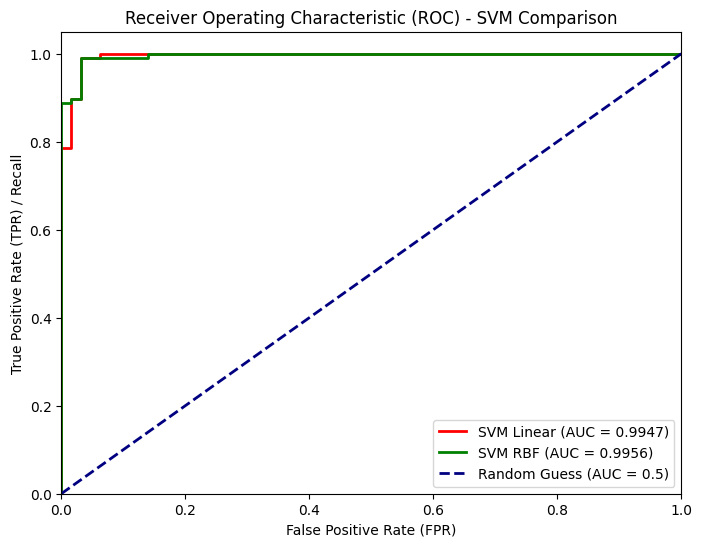

In [ ]:
#plot ROC for tow models
y_scores_linear = svm_linear.predict_proba(X_test_scaled)
y_scores_rbf = gs_rbf.predict_proba(X_test_scaled)

# Calculating the ROC Curve and the key points (FPR, TPR) and AUC for each model
# For the linear model SVM
fpr_linear, tpr_linear, _ = roc_curve(y_test, y_scores_linear[:, 1])
roc_auc_linear = roc_auc_score(y_test, y_scores_linear[:, 1])

# for non Linear SVM (RBF)
fpr_rbf, tpr_rbf, _ = roc_curve(y_test, y_scores_rbf[:, 1])
roc_auc_rbf = roc_auc_score(y_test, y_scores_rbf[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr_linear, tpr_linear, color='red', lw=2,
         label=f'SVM Linear (AUC = {roc_auc_linear:0.4f})')
plt.plot(fpr_rbf, tpr_rbf, color='green', lw=2,
         label=f'SVM RBF (AUC = {roc_auc_rbf:0.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('Receiver Operating Characteristic (ROC) - SVM Comparison')
plt.legend(loc='lower right')
plt.savefig('SVM_ROC_Curve_Dataset1.png')

In [ ]:
# pripring the data for unsupervised
scaler = StandardScaler()
X_scaled_unsupervised = scaler.fit_transform(X)

In [ ]:
# k-means model with k=2
kmeans = KMeans(n_clusters=2, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_scaled_unsupervised) # fit WITHOUT labels
print("Silhouette Score (KMeans):", silhouette_score(X_scaled_unsupervised, clusters_kmeans))

Silhouette Score (KMeans): 0.3447344346611054


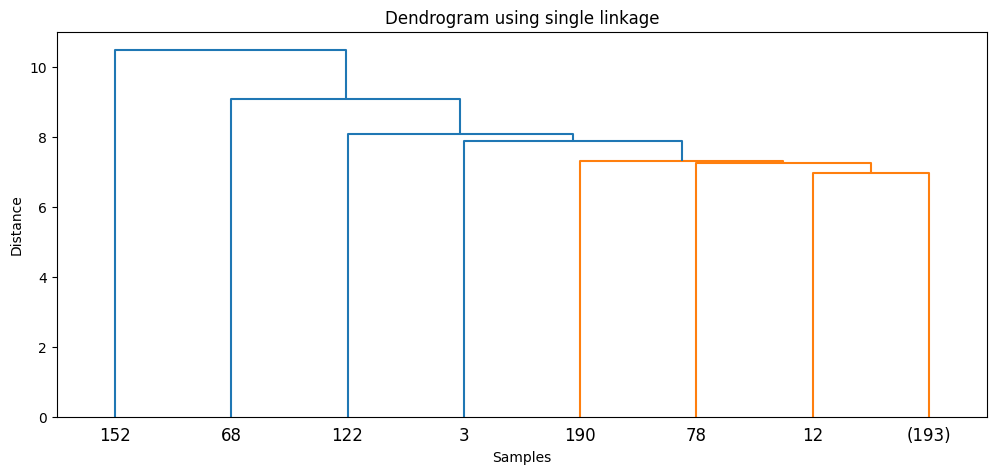

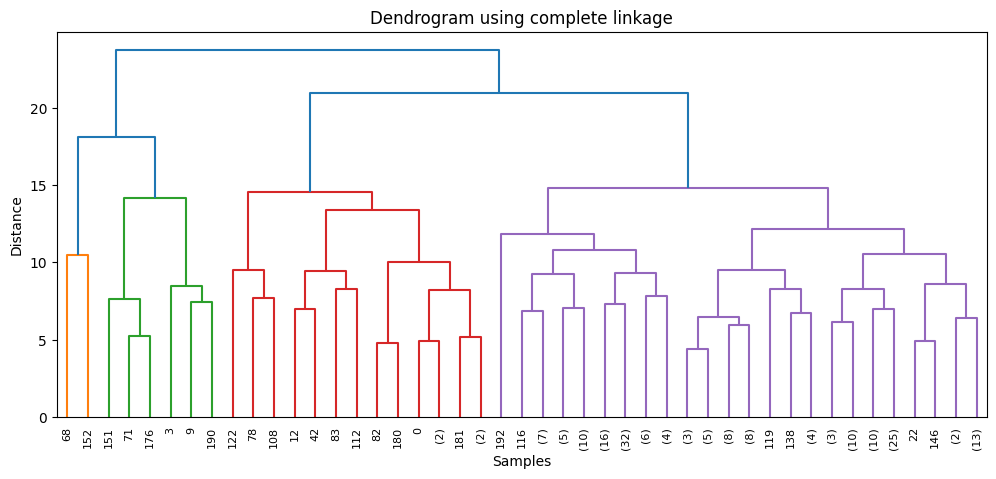

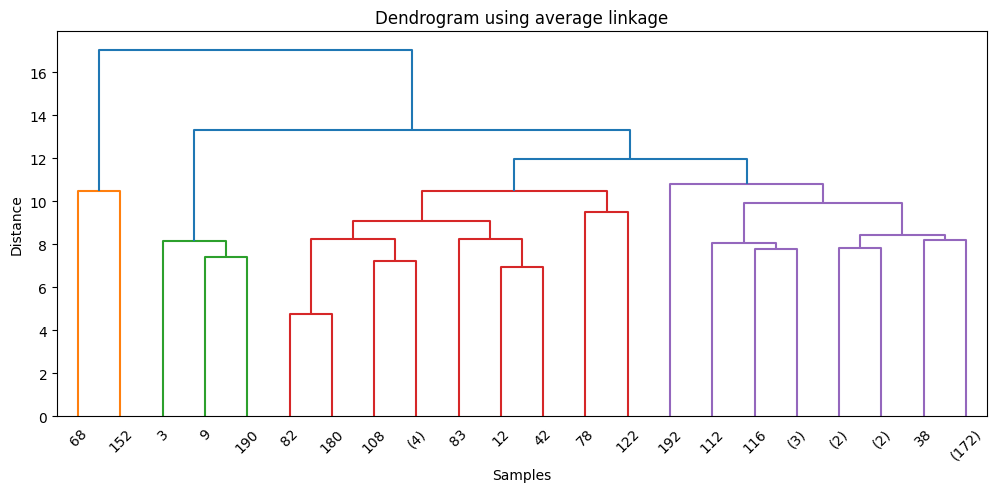

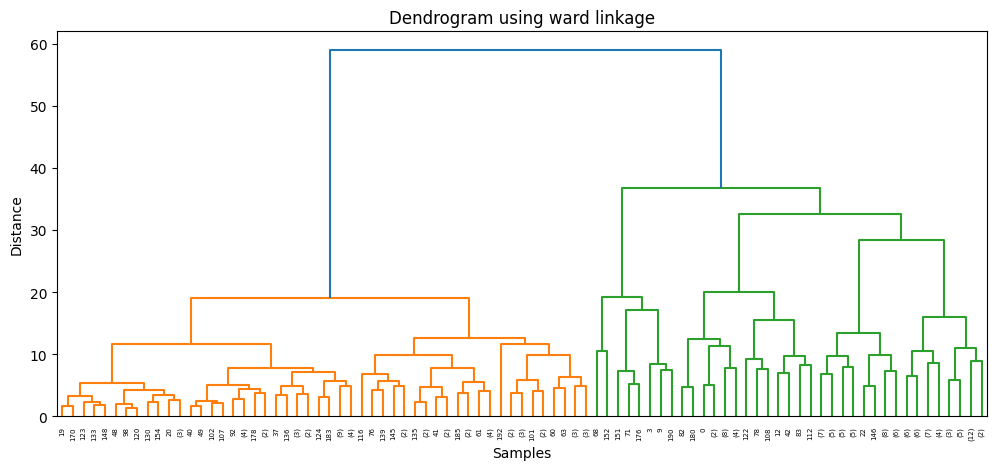

In [ ]:
# plot dendrogram
methods = ["single", "complete", "average", "ward"]
# use sample of data to make it clear and faster (200 sample)
subset_n = 200 if X_scaled_unsupervised.shape[0] >= 200 else X_scaled_unsupervised.shape[0]
X_sub = X_scaled_unsupervised[:subset_n]

for m in methods:
    plt.figure(figsize=(12, 5))
    Z = linkage(X_sub, method=m)
    dendrogram(Z, truncate_mode="level", p=6)
    plt.title(f"Dendrogram using {m} linkage")
    plt.xlabel("Samples")
    plt.ylabel("Distance")
    plt.show()

In [ ]:
# Hierarchical model
# At first, I wrote this code, but later I changed it because I felt it was difficult to understand, and I replaced it with a simpler code below.
#agg = AgglomerativeClustering(n_clusters=2)
#clusters_agg = agg.fit_predict(X_scaled_unsupervised)
#print("Silhouette Score (Hierarchical):", silhouette_score(X_scaled_unsupervised, clusters_agg))

   #linkage_methods = ['single', 'complete', 'average']  # at least two required; I use three
#clusters_hier = {}   # store labels for each linkage
#sil_scores_hier = {}

#for method in linkage_methods:
   # agg = AgglomerativeClustering(n_clusters=2, linkage=method)
   # labels = agg.fit_predict(X_scaled_unsupervised)   # fit WITHOUT labels
   # clusters_hier[method] = labels
   # sil = silhouette_score(X_scaled_unsupervised, labels)
#    sil_scores_hier[method] = sil
   # print(f"Agglomerative ({method}) -> silhouette score: {sil:.4f}")

 # Single linkage
agg_single = AgglomerativeClustering(n_clusters=2, linkage='single')
clusters_single = agg_single.fit_predict(X_scaled_unsupervised)

# Complete linkage
agg_complete = AgglomerativeClustering(n_clusters=2, linkage='complete')
clusters_complete = agg_complete.fit_predict(X_scaled_unsupervised)

# Average linkage
agg_average = AgglomerativeClustering(n_clusters=2, linkage='average')
clusters_average = agg_average.fit_predict(X_scaled_unsupervised)

# --- Silhouette for Hierarchical ---
sil_single = silhouette_score(X_scaled_unsupervised, clusters_single)
sil_complete = silhouette_score(X_scaled_unsupervised, clusters_complete)
sil_average = silhouette_score(X_scaled_unsupervised, clusters_average)

print("Silhouette (Hierarchical - single):", sil_single)
print("Silhouette (Hierarchical - complete):", sil_complete)
print("Silhouette (Hierarchical - average):", sil_average)


Silhouette (Hierarchical - single): 0.6606668813897673
Silhouette (Hierarchical - complete): 0.6606668813897673
Silhouette (Hierarchical - average): 0.6339782218419878


In [ ]:
# Compare clusters with true labels
print("\n=== K-Means vs True Labels ===")
table_km = pd.crosstab(clusters_kmeans, y, rownames=["Cluster"], colnames=["True Label"])
print(table_km)

print("\n=== Hierarchical (average) vs True Labels ===")
print(pd.crosstab(clusters_average, y, rownames=["Cluster"], colnames=["True Label"]))

print("\n=== Hierarchical (single) vs True Labels ===")
print(pd.crosstab(clusters_single, y, rownames=["Cluster"], colnames=["True Label"]))

print("\n=== Hierarchical (complete) vs True Labels ===")
print(pd.crosstab(clusters_complete, y, rownames=["Cluster"], colnames=["True Label"]))


=== K-Means vs True Labels ===
True Label    0    1
Cluster             
0           175   13
1            37  344

=== Hierarchical (average) vs True Labels ===
True Label    0    1
Cluster             
0           209  357
1             3    0

=== Hierarchical (single) vs True Labels ===
True Label    0    1
Cluster             
0           210  357
1             2    0

=== Hierarchical (complete) vs True Labels ===
True Label    0    1
Cluster             
0           210  357
1             2    0


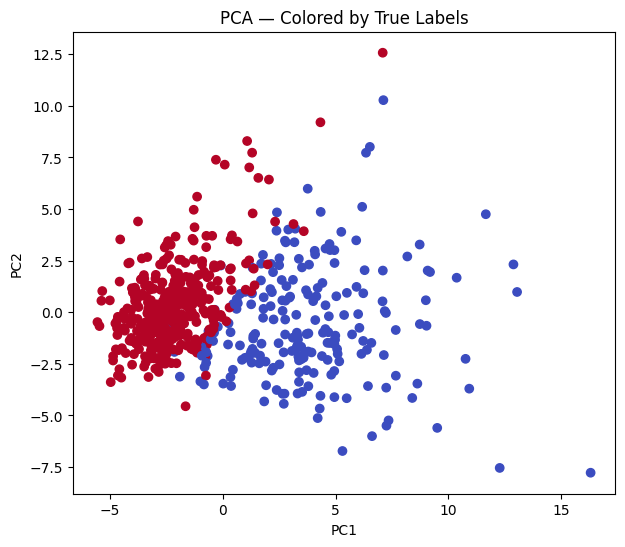

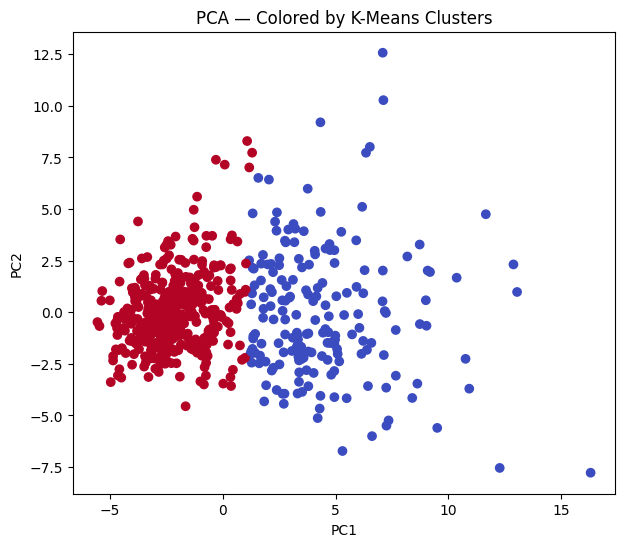

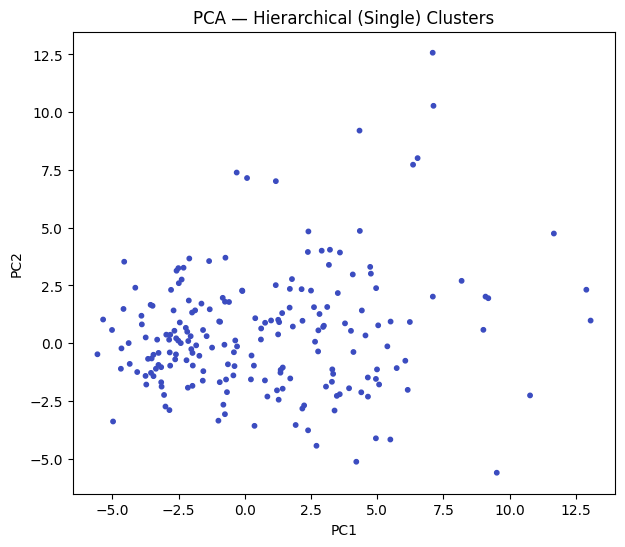

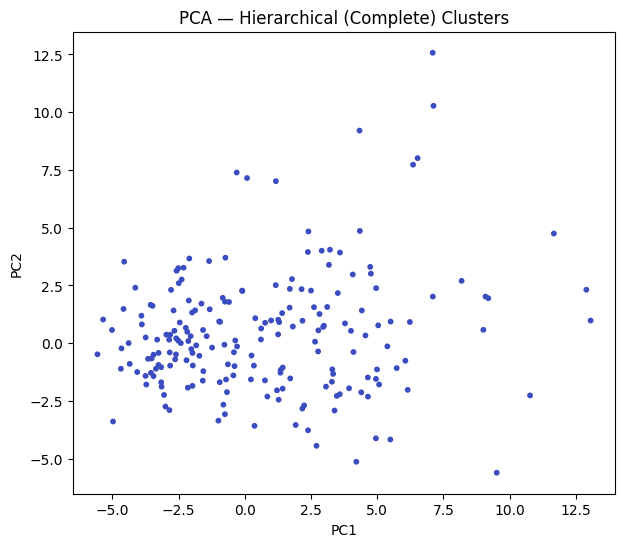

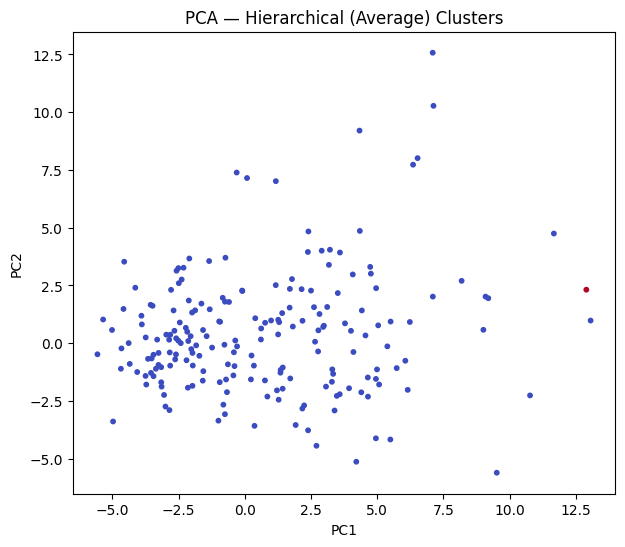

In [ ]:
# plot PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_unsupervised)
X_pca_sample = pca.transform(X_sub)

# True Labels
plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="coolwarm")
plt.title("PCA — Colored by True Labels")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# K-Means Clusters
plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_kmeans, cmap="coolwarm")
plt.title("PCA — Colored by K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Hierarchical (Single) Clusters
plt.figure(figsize=(7,6))
plt.scatter(X_pca_sample[:,0], X_pca_sample[:,1], c=clusters_single[:subset_n], cmap='coolwarm', s=10)
plt.title("PCA — Hierarchical (Single) Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Hierarchical (Complete) Clusters
plt.figure(figsize=(7,6))
plt.scatter(X_pca_sample[:,0], X_pca_sample[:,1], c=clusters_complete[:subset_n], cmap='coolwarm', s=10)
plt.title("PCA — Hierarchical (Complete) Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Hierarchical (Average) Clusters
plt.figure(figsize=(7,6))
plt.scatter(X_pca_sample[:,0], X_pca_sample[:,1], c=clusters_average[:subset_n], cmap='coolwarm', s=10)
plt.title("PCA — Hierarchical (Average) Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Q4:

1.
SVM provided high and excellent performance compared to the clustering algorithms, and the reason is that it is a supervised method meaning it has labels to learn from during training. Therefore, it can learn the decision boundaries better and produce high accuracy and strong performance, and it can recognize complex patterns if they exist.
But for K-Means, it does not see the labels, so it does not learn in the same way. Instead, it assumes that the data forms clusters around certain centers. The dataset had clear and good separation, but not perfect, and the model delivered medium-to-good performance, as shown in the comparison with the true labels and PCA plot. It was able to learn and separate the two groups reasonably well even though there were some mistakes. However, it gave a Silhouette score that indicates medium-to-weak clustering quality, meaning lower cohesion within clusters and lower separation between them.
As for Hierarchical clustering, it gave me a medium-to-high Silhouette score, meaning good clustering quality with higher cohesion within clusters and higher separation between them. But when I looked at the plots and the comparison with the true label, I discovered that the model did not actually learn the separation well. It placed almost all data points into one cluster and put the outliers into the other cluster. This means its results are not reliable or logical.
Therefore, I can say that SVM had the best performance, then K-Means, and finally Hierarchical.

2.
SVM was the best at separating the classes because it trained on labeled data, which allowed it to learn excellent decision boundaries. The model also searches for the best hyperplane that separates the two classes with the largest margin. Using scaling made the boundaries clearer, and the RBF kernel can learn and discover non-linear relationships, so the model achieved very high and excellent performance.
In contrast, the other two models are unsupervised, meaning they do not have labels and depend only on distances.

3.
Scaling had a major and very important impact on the results of all models, because all of them depend on or need distance calculations. If there is a feature that dominates the distances or has a large influence, the results would become bad—the model could classify incorrectly, become biased, or even give random results. Therefore, scaling was necessary and very important.
As for encoding, I did not apply it because the dataset came already encoded when I loaded it, but it is also important and affects the plots and results later.

4.
I recommend the SVM model because it had the highest accuracy and the best performance in separating and learning the data—specifically the linear SVM, then the non-linear one. Both performed excellently, but the linear one was slightly better.
Next comes K-Means. Although it did not give very high clustering quality, it still delivered good performance and was able to separate the two classes reasonably well, which is acceptable, with good speed.
Finally, Hierarchical clustering gave almost high clustering quality, but in reality it could not learn or classify the classes correctly. It can be used for exploring data and identifying outliers, but not for classification or prediction.